In [1]:
import math
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch import onnx
import matplotlib.pyplot as plt


In [2]:
BOARD_SIZE = 5
K = 4  # four in a row


def has_four_in_a_row(board):
    # Rows
    for r in range(BOARD_SIZE):
        for c in range(BOARD_SIZE - K + 1):
            w = board[r, c:c+K]
            if abs(w.sum()) == K:
                return True

    # Columns
    for c in range(BOARD_SIZE):
        for r in range(BOARD_SIZE - K + 1):
            w = board[r:r+K, c]
            if abs(w.sum()) == K:
                return True

    # Diagonal \
    for r in range(BOARD_SIZE - K + 1):
        for c in range(BOARD_SIZE - K + 1):
            w = np.array([board[r+i, c+i] for i in range(K)])
            if abs(w.sum()) == K:
                return True

    # Diagonal /
    for r in range(BOARD_SIZE - K + 1):
        for c in range(K - 1, BOARD_SIZE):
            w = np.array([board[r+i, c-i] for i in range(K)])
            if abs(w.sum()) == K:
                return True

    return False

def action_to_index(row, col, symbol):
    sym = 0 if symbol == 1 else 1
    return row * 10 + col * 2 + sym

def index_to_action(idx):
    row = idx // 10
    col = (idx % 10) // 2
    symbol = 1 if idx % 2 == 0 else -1
    return row, col, symbol

def encode_state(board, current_player):
    x_plane = (board == 1).astype(np.float32)
    o_plane = (board == -1).astype(np.float32)
    empty_plane = (board == 0).astype(np.float32)
    turn_plane = np.ones_like(board, dtype=np.float32) \
        if current_player == 1 else np.zeros_like(board, dtype=np.float32)

    return np.stack([x_plane, o_plane, empty_plane, turn_plane], axis=0)



In [3]:
#test call

# Horizontal
b = np.zeros((5,5), dtype=int)
b[2, 0:4] = 1
assert has_four_in_a_row(b)

# Vertical
b = np.zeros((5,5), dtype=int)
b[0:4, 3] = -1
assert has_four_in_a_row(b)

# Diagonal \
b = np.zeros((5,5), dtype=int)
for i in range(4):
    b[i, i] = 1
assert has_four_in_a_row(b)

# Diagonal /
b = np.zeros((5,5), dtype=int)
for i in range(4):
    b[i, 4-i] = -1
assert has_four_in_a_row(b)

# Negative case
b = np.zeros((5,5), dtype=int)
b[0, 0:3] = 1
assert not has_four_in_a_row(b)

print("All tests passed")


All tests passed


In [4]:
class OrderChaosGame:
    def __init__(self):
        self.board = np.zeros((5, 5), dtype=np.int8)
        self.player = 1  # Order starts

    def clone(self):
        g = OrderChaosGame()
        g.board = self.board.copy()
        g.player = self.player
        return g

    def legal_actions(self):
        actions = []
        for r in range(5):
            for c in range(5):
                if self.board[r, c] == 0:
                    actions.append(action_to_index(r, c, 1))
                    actions.append(action_to_index(r, c, -1))
        return actions

    def apply(self, action_idx):
        r, c, s = index_to_action(action_idx)
        assert self.board[r, c] == 0
        self.board[r, c] = s
        self.player *= -1

    def terminal(self):
        if has_four_in_a_row(self.board):
            return True, 1  # Order wins when four in a row
        if np.all(self.board != 0):
            return True, -1  # Chaos wins on full board
        return False, 0

In [5]:
class MaxwellsDemonNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(4, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)

        # Policy head
        self.policy_conv = nn.Conv2d(64, 2, 1)
        self.policy_fc = nn.Linear(2 * 5 * 5, 50)

        # Value head
        self.value_conv = nn.Conv2d(64, 1, 1)
        self.value_fc1 = nn.Linear(25, 64)
        self.value_fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        p = F.relu(self.policy_conv(x))
        p = p.view(p.size(0), -1)
        p = F.softmax(self.policy_fc(p), dim=1)

        v = F.relu(self.value_conv(x))
        v = v.view(v.size(0), -1)
        v = F.relu(self.value_fc1(v))
        v = torch.tanh(self.value_fc2(v))

        return p, v


In [6]:
class MCTSNode:
    def __init__(self, prior):
        self.P = prior          # prior probability
        self.N = 0              # visit count
        self.W = 0.0            # total value
        self.children = {}      # action_idx -> MCTSNode

    @property
    def Q(self):
        return 0 if self.N == 0 else self.W / self.N


In [7]:
def puct(parent, child, c_puct=1.0):
    return child.Q + c_puct * child.P * math.sqrt(parent.N) / (1 + child.N)

def run_mcts(root_game: OrderChaosGame, net, simulations=100, c_puct=1.0):
    device = next(net.parameters()).device
    root = MCTSNode(prior=1.0)

    for _ in range(simulations):
        node = root
        game = root_game.clone()
        path = []

        # Selection
        while node.children:
            action, node = max(
                node.children.items(),
                key=lambda x: puct(path[-1] if path else root, x[1], c_puct)
            )
            game.apply(action)
            path.append(node)
        
        # Terminal check
        terminal, winner = game.terminal()
        if terminal:
            value = winner if game.player == 1 else -winner
        else:
            # Evaluation
            state = torch.tensor(
                encode_state(game.board, game.player),
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            with torch.no_grad():
                policy, value = net(state)
                policy = policy.cpu().numpy()[0]
                value = value.item()

            # Expand
            legal = game.legal_actions()
            policy_masked = np.zeros(50)
            policy_masked[legal] = policy[legal]
            if policy_masked.sum() > 0:
                policy_masked /= policy_masked.sum()
            else:
                policy_masked[legal] = 1 / len(legal)

            for a in legal:
                node.children[a] = MCTSNode(policy_masked[a])

        # Backup
        for n in reversed(path):
            n.N += 1
            n.W += value
            value = -value

        root.N += 1
        root.W += value

    # Improved policy
    pi = np.zeros(50)
    for a, child in root.children.items():
        pi[a] = child.N

    pi /= pi.sum()
    return pi


In [8]:
def sample_from_pi(pi, temperature=1.0):
    if temperature <= 1e-8:
        return int(np.argmax(pi))

    # Temperature scaling: lower temp -> greedier
    p = np.asarray(pi, dtype=np.float64) ** (1.0 / temperature)
    s = p.sum()
    if s <= 0:
        return int(np.argmax(pi))
    p /= s
    return int(np.random.choice(len(p), p=p))

def self_play_game(net, simulations=100, temp_moves=10, temp=1.0):
    game = OrderChaosGame()
    data = []
    move_count = 0

    while True:
        # Run MCTS from current position
        pi = run_mcts(game, net, simulations=simulations)

        # Store training example
        state = encode_state(game.board, game.player)
        data.append((state, pi, game.player))

        # Choose move (argmax for now)
        # action = np.argmax(pi)
        if move_count < temp_moves:
            action = sample_from_pi(pi, temperature=temp)   # exploration early
        else:
            action = int(np.argmax(pi))                     # greedy later
        game.apply(action)
        move_count += 1

        terminal, winner = game.terminal()
        if terminal:
            break

    # Assign final outcomes
    final_data = []
    for state, pi, player in data:
        z = winner if player == 1 else -winner
        final_data.append((state, pi, z))

    return final_data

def az_loss(p_pred, v_pred, pi_target, z_target):
    value_loss = F.mse_loss(v_pred.squeeze(), z_target)
    policy_loss = -(pi_target * torch.log(p_pred + 1e-8)).sum(dim=1).mean()
    return value_loss + policy_loss

def train_step(net, optimizer, batch):
    states, pis, zs = zip(*batch)


    states = torch.from_numpy(np.array(states, dtype=np.float32))
    pis    = torch.from_numpy(np.array(pis, dtype=np.float32))
    zs     = torch.from_numpy(np.array(zs, dtype=np.float32))

    p_pred, v_pred = net(states)
    loss = az_loss(p_pred, v_pred, pis, zs)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()



In [ ]:
#Training loop

replay_buffer = []
NUM_ITERATIONS = 500
BATCH_SIZE = 128
MAX_BUFFER_SIZE = 35000
SELF_PLAY_GAMES = 100
SIMULATIONS_PER_MOVE = 400
NUM_GRADIENT_STEPS = 70
mean_loss_history = {}

net = MaxwellsDemonNet()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

for iteration in range(NUM_ITERATIONS):
    print(f"\n=== Iteration {iteration} ===")

    # --- Self-play ---
    net.eval()
    for g in range(SELF_PLAY_GAMES):
        game_data = self_play_game(net, simulations=SIMULATIONS_PER_MOVE)
        replay_buffer.extend(game_data)

    # Trim buffer
    if len(replay_buffer) > MAX_BUFFER_SIZE:
        replay_buffer = replay_buffer[-MAX_BUFFER_SIZE:]

    print(f"Replay buffer size: {len(replay_buffer)}")

    # --- Training ---
    net.train()
    losses = []

    for _ in range(NUM_GRADIENT_STEPS):  #gradient steps per iteration
        batch = random.sample(
            replay_buffer,
            min(BATCH_SIZE, len(replay_buffer))
        )
        loss = train_step(net, optimizer, batch)
        losses.append(loss)

    print(f"Mean loss: {sum(losses)/len(losses):.4f}")
    mean_loss_history[iteration + 1] = sum(losses)/len(losses)
    #checkpoint
    if (iteration + 1) % 25 == 0:  # save every 25 iterations
        torch.save(
            {
                "model_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "iteration": iteration + 1,
                "replay_buffer": replay_buffer,
                "mean_loss_history": mean_loss_history,
            },
            "maxwells_demon_checkpoint.pt",
        )



=== Iteration 0 ===
Replay buffer size: 1109
Mean loss: 4.2106

=== Iteration 1 ===
Replay buffer size: 2831
Mean loss: 3.6813

=== Iteration 2 ===
Replay buffer size: 4540
Mean loss: 3.3086

=== Iteration 3 ===
Replay buffer size: 5996
Mean loss: 3.0818

=== Iteration 4 ===
Replay buffer size: 7546
Mean loss: 2.9065

=== Iteration 5 ===
Replay buffer size: 9028
Mean loss: 2.8125

=== Iteration 6 ===
Replay buffer size: 10536
Mean loss: 2.7324

=== Iteration 7 ===
Replay buffer size: 12070
Mean loss: 2.6829

=== Iteration 8 ===
Replay buffer size: 13720
Mean loss: 2.6379

=== Iteration 9 ===
Replay buffer size: 15304
Mean loss: 2.6069

=== Iteration 10 ===
Replay buffer size: 16805
Mean loss: 2.6073

=== Iteration 11 ===
Replay buffer size: 18355
Mean loss: 2.5800

=== Iteration 12 ===
Replay buffer size: 19875
Mean loss: 2.5685

=== Iteration 13 ===
Replay buffer size: 21345
Mean loss: 2.5433

=== Iteration 14 ===
Replay buffer size: 22829
Mean loss: 2.5416

=== Iteration 15 ===
Repl

Text(0.5, 1.0, 'Training Loss')

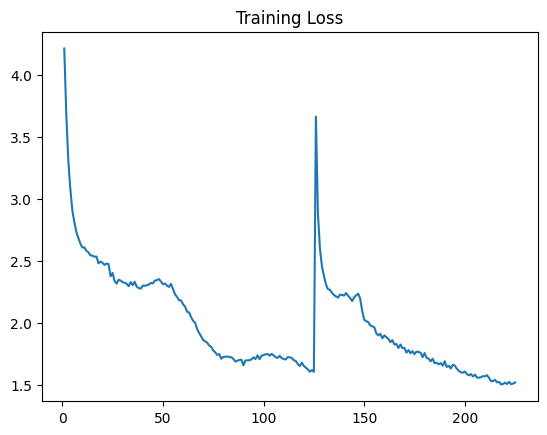

In [25]:
checkpoint = torch.load("maxwells_demon_checkpoint.pt")

net = MaxwellsDemonNet()

net.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
mean_loss_history = checkpoint["mean_loss_history"]
current_iteration = checkpoint["iteration"]
replay_buffer = checkpoint["replay_buffer"]


plt.plot(list(mean_loss_history.keys()), list(mean_loss_history.values()))
plt.title("Training Loss")

In [26]:
#retrain

#Training loop

NUM_ITERATIONS = 100
BATCH_SIZE = 128
MAX_BUFFER_SIZE = 35000
SELF_PLAY_GAMES = 100
SIMULATIONS_PER_MOVE = 400
NUM_GRADIENT_STEPS = 70

net = MaxwellsDemonNet()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

for iteration in range(current_iteration, current_iteration + NUM_ITERATIONS):
    print(f"\n=== Iteration {iteration} ===")

    # --- Self-play ---
    net.eval()
    for g in range(SELF_PLAY_GAMES):
        game_data = self_play_game(net, simulations=SIMULATIONS_PER_MOVE)
        replay_buffer.extend(game_data)

    # Trim buffer
    if len(replay_buffer) > MAX_BUFFER_SIZE:
        replay_buffer = replay_buffer[-MAX_BUFFER_SIZE:]

    print(f"Replay buffer size: {len(replay_buffer)}")

    # --- Training ---
    net.train()
    losses = []

    for _ in range(NUM_GRADIENT_STEPS):  #gradient steps per iteration
        batch = random.sample(
            replay_buffer,
            min(BATCH_SIZE, len(replay_buffer))
        )
        loss = train_step(net, optimizer, batch)
        losses.append(loss)

    mean_loss_history[iteration + 1] = sum(losses)/len(losses)
    print(f"Mean loss: {mean_loss_history[iteration + 1]:.4f}")
    #checkpoint
    if (iteration + 1) % 25 == 0:  # save every 25 iterations
        print(f"Saving checkpoint at iteration {iteration + 1}...")
        torch.save(
            {
                "model_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "iteration": iteration + 1,
                "replay_buffer": replay_buffer,
                "mean_loss_history": mean_loss_history,
            },
            "maxwells_demon_checkpoint.pt",
        )



=== Iteration 225 ===
Replay buffer size: 35000
Mean loss: 3.8676

=== Iteration 226 ===
Replay buffer size: 35000
Mean loss: 2.8478

=== Iteration 227 ===
Replay buffer size: 35000
Mean loss: 2.4453

=== Iteration 228 ===
Replay buffer size: 35000
Mean loss: 2.2608

=== Iteration 229 ===
Replay buffer size: 35000
Mean loss: 2.1535

=== Iteration 230 ===
Replay buffer size: 35000
Mean loss: 2.0997

=== Iteration 231 ===
Replay buffer size: 35000
Mean loss: 2.0718

=== Iteration 232 ===
Replay buffer size: 35000
Mean loss: 2.0617

=== Iteration 233 ===
Replay buffer size: 35000
Mean loss: 2.0149

=== Iteration 234 ===
Replay buffer size: 35000
Mean loss: 2.0185

=== Iteration 235 ===
Replay buffer size: 35000
Mean loss: 2.0099

=== Iteration 236 ===
Replay buffer size: 35000
Mean loss: 2.0418

=== Iteration 237 ===
Replay buffer size: 35000
Mean loss: 2.0222

=== Iteration 238 ===
Replay buffer size: 35000
Mean loss: 1.9716

=== Iteration 239 ===
Replay buffer size: 35000
Mean loss: 2.

In [27]:
#test model outputs for an array of inputs of different board states

net.eval()
test_states = [
    encode_state(np.zeros((5, 5), dtype=np.int8), 1),  # Empty board, Order's turn
    encode_state(np.array([[1, -1, 0, 0, 0],
                           [0, 1, -1, 0, 0],
                           [0, 0, 1, -1, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0]], dtype=np.int8), 1),  # Near win
    encode_state(np.array([[0, 1, 1, 1, 0],
                           [-1, -1, -1, 0, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0]], dtype=np.int8), -1),  # Near loss
    # near winning situation for chaos, there need to be an odd number of moves playes as well
    encode_state(np.array([[ 1, 1, 1, 0,-1],
                           [-1,-1, -1, 1, 0],
                           [ 0, 1,-1, -1, 0],
                           [ 0, 0, 1, 1, 0],
                           [ 0, -1, 0, 1, 0]], dtype=np.int8), -1)
]
for i, state in enumerate(test_states):
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        policy, value = net(state_tensor)
    print(f"Test State {i}:")
    print(f"best move: {index_to_action(np.argmax(policy.cpu()).item())}")
    print(f"Value: {value.item()}\n")

Test State 0:
best move: (3, 2, -1)
Value: 0.993012547492981

Test State 1:
best move: (3, 2, -1)
Value: 0.9856575131416321

Test State 2:
best move: (2, 0, 1)
Value: -0.9943333864212036

Test State 3:
best move: (4, 4, -1)
Value: -0.9995667934417725



In [28]:
# Export to ONNX
net.eval()
net.cpu()

output_path = "../frontend/public/maxwells_demon.onnx"

dummy_input = torch.zeros(
    1, 4, 5, 5,
    dtype=torch.float32
)

torch.onnx.export(
    net,
    dummy_input,
    output_path,
    input_names=["board"],
    output_names=["policy", "value"],
    dynamic_axes={
        "board": {0: "batch"},
        "policy": {0: "batch"},
        "value": {0: "batch"}
    },
    opset_version=17
)

